# CSE425 — Exploratory Data Analysis
### Graph Neural Networks + BERT for Music Context Understanding

This notebook documents what is actually *in* the four corpora this project uses, and
derives the preprocessing decisions from that evidence rather than from defaults.
Every figure here is produced from the files in `data/`; nothing is illustrative.

**What we look at**

1. The four corpora and what each one can and cannot supervise
2. MusicCaps captions — length, vocabulary, and the lexical shortcut problem
3. GTZAN — why the *fault-filtered* split is used instead of a random one
4. DEAM — the valence/arousal circumplex
5. Audio → features → segments → graph, one track end to end
6. Calibrating the similarity threshold τ
7. Chord-transition graphs
8. Graph statistics across corpora, and what they imply for the GNN depth

In [1]:
import json, sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

from src.utils import ROOT, load_config, set_seed
from src.data_loading import GTZAN_GENRES, load_deam, load_gtzan, load_musiccaps

cfg = load_config()
set_seed(cfg["seed"])
sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95)
PALETTE = sns.color_palette("colorblind")
print("repo root:", ROOT)
print("seed:", cfg["seed"], "| device:", cfg["device"])

repo root: U:\test 1\gnn-bert-music-context
seed: 425 | device: cpu


## 1. The four corpora

Each corpus supervises something different, and no single one supervises the whole
task. That asymmetry is the reason the project needs four tasks rather than one.

| corpus | audio | text | labels | used for |
|---|---|---|---|---|
| GTZAN | 1000 × 30 s | genre name only | 10 genres, single-label | Task 2 (graph-only genre) |
| MusicCaps | YouTube IDs → 10 s clips | human captions | free-text aspects → top-50 tags | Tasks 1, 3, 4 |
| DEAM | 1802 × 45 s | release metadata | valence/arousal, 1–9 | Task 3 (emotion head) |
| FMA-medium | 25 k × 30 s | track metadata | 16 top genres | optional scale-up |

MusicCaps ships **no audio** — only YouTube IDs — so its usable size is whatever
fraction of those videos are still downloadable. That recovery rate is measured, not
assumed, and is reported with every MusicCaps number in the paper.

In [2]:
gtzan = load_gtzan(cfg)
mc, vocab = load_musiccaps(cfg)
deam = load_deam(cfg)

rows = []
for name, df in (("GTZAN", gtzan), ("MusicCaps", mc), ("DEAM", deam)):
    rows.append({
        "corpus": name,
        "items": len(df),
        "train": int((df["split"] == "train").sum()),
        "val": int((df["split"] == "val").sum()),
        "test": int((df["split"] == "test").sum()),
    })
overview = pd.DataFrame(rows).set_index("corpus")
display(overview)

print(f"MusicCaps audio recovery: {mc['audio_exists'].sum()}/{len(mc)} clips "
      f"= {mc['audio_exists'].mean():.1%}")
print(f"tag vocabulary: {len(vocab.tags)} tags")

skipping known-corrupt GTZAN file jazz.00054


,items,train,val,test
corpus,,,,
GTZAN,929,442,197,290
MusicCaps,4995,1981,435,2579
DEAM,1802,1261,270,271


MusicCaps audio recovery: 1507/4995 clips = 30.2%
tag vocabulary: 50 tags


## 2. MusicCaps captions

### 2a. Caption length

This sets `text.max_length`. If the 95th percentile sits far below the configured
length, the padding is pure wasted compute; if it sits above, the model is being
trained on truncated evidence.

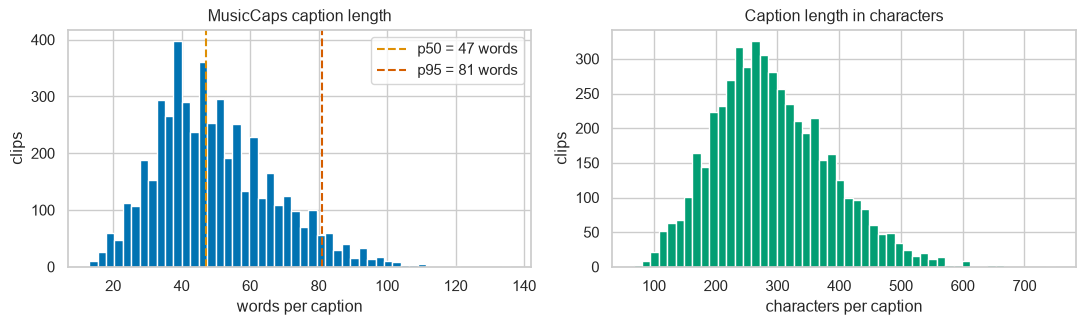

words: mean 49.7  median 47  p95 81  max 136
configured text.max_length = 192 wordpiece tokens


In [3]:
lens_words = mc["caption"].str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(lens_words, bins=50, color=PALETTE[0])
for q, c in ((0.5, PALETTE[1]), (0.95, PALETTE[3])):
    v = lens_words.quantile(q)
    axes[0].axvline(v, ls="--", color=c, label=f"p{int(q*100)} = {v:.0f} words")
axes[0].set(xlabel="words per caption", ylabel="clips", title="MusicCaps caption length")
axes[0].legend()

axes[1].hist(mc["caption"].str.len(), bins=50, color=PALETTE[2])
axes[1].set(xlabel="characters per caption", ylabel="clips", title="Caption length in characters")
plt.tight_layout(); plt.show()

print(f"words: mean {lens_words.mean():.1f}  median {lens_words.median():.0f}  "
      f"p95 {lens_words.quantile(0.95):.0f}  max {lens_words.max()}")
print(f"configured text.max_length = {cfg['text']['max_length']} wordpiece tokens")

### 2b. The tag vocabulary

MusicCaps' `aspect_list` is free text with a very long tail, so the label space is
built by taking the 50 most frequent aspects. The tail is genuinely long — most
aspects appear a handful of times — and a model cannot be evaluated on labels with
single-digit support.

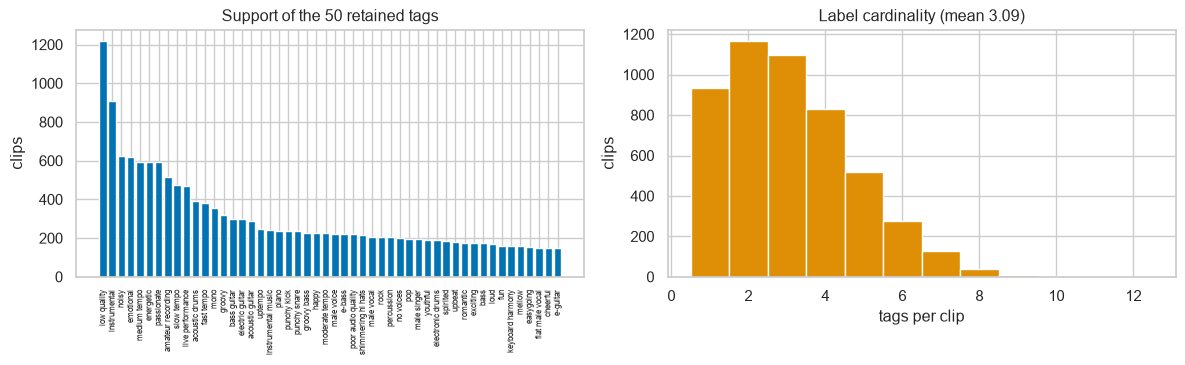

most frequent : low quality, instrumental, noisy, emotional, medium tempo, energetic, passionate, amateur recording
least frequent: loud, fun, keyboard harmony, mellow, easygoing, flat male vocal, cheerful, e-guitar
support range : 147 .. 1217 clips
imbalance     : 8.3x commonest vs rarest


In [4]:
Y = np.stack(mc["y"].to_list())
support = Y.sum(0).astype(int)
order = np.argsort(-support)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(range(len(order)), support[order], color=PALETTE[0])
axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels([vocab.tags[i] for i in order], rotation=90, fontsize=6)
axes[0].set(ylabel="clips", title=f"Support of the {len(vocab.tags)} retained tags")

card = Y.sum(1)
axes[1].hist(card, bins=range(1, int(card.max()) + 2), color=PALETTE[1], align="left")
axes[1].set(xlabel="tags per clip", ylabel="clips",
            title=f"Label cardinality (mean {card.mean():.2f})")
plt.tight_layout(); plt.show()

print(f"most frequent : {', '.join(vocab.tags[i] for i in order[:8])}")
print(f"least frequent: {', '.join(vocab.tags[i] for i in order[-8:])}")
print(f"support range : {support.min()} .. {support.max()} clips")
print(f"imbalance     : {support.max() / support.min():.1f}x commonest vs rarest")

### 2c. Tag co-occurrence

Multi-label metrics are only interpretable if you know how correlated the labels are.
Strongly co-occurring pairs mean a model can score well on micro-F1 by learning a
handful of clusters, which is why macro-F1 is the headline metric here.

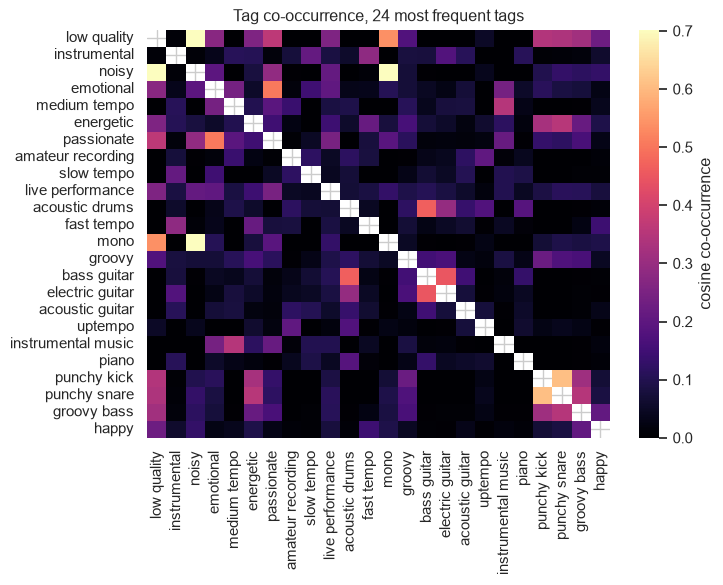

strongest co-occurring pairs:
  0.702  low quality              + noisy
  0.700  noisy                    + mono
  0.607  punchy kick              + punchy snare
  0.540  low quality              + mono
  0.507  emotional                + passionate
  0.465  acoustic drums           + bass guitar
  0.448  bass guitar              + electric guitar
  0.363  low quality              + passionate


In [5]:
top = order[:24]
Yt = Y[:, top]
co = (Yt.T @ Yt).astype(float)
denom = np.sqrt(np.outer(np.diag(co), np.diag(co)))
cosim = co / np.maximum(denom, 1)          # cosine over the label indicator vectors
np.fill_diagonal(cosim, np.nan)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cosim, xticklabels=[vocab.tags[i] for i in top],
            yticklabels=[vocab.tags[i] for i in top], cmap="magma", ax=ax,
            cbar_kws={"label": "cosine co-occurrence"})
ax.set_title("Tag co-occurrence, 24 most frequent tags")
plt.tight_layout(); plt.show()

pairs = []
for a in range(len(top)):
    for b in range(a + 1, len(top)):
        pairs.append((cosim[a, b], vocab.tags[top[a]], vocab.tags[top[b]]))
print("strongest co-occurring pairs:")
for v, a, b in sorted(pairs, reverse=True)[:8]:
    print(f"  {v:.3f}  {a:<24s} + {b}")

### 2d. The lexical shortcut

This is the single most important observation in the EDA, and it changes how Task 1
has to be evaluated.

MusicCaps tags are *derived from the captions*. So a caption that earns the tag
`"acoustic guitar"` very often contains the literal string "acoustic guitar". A text
model can score highly by pattern-matching the label out of its own input, which
measures nothing about music understanding.

Two consequences, both implemented:

* a **lexical-match baseline** (B0) that predicts a tag iff its surface form occurs
  in the caption — this quantifies the size of the shortcut;
* a **masked-caption variant** where every retained tag's surface form is stripped
  from the caption before tokenisation, so the model must infer the tag from the
  surrounding description.

The gap between the naive and masked variants is reported in the paper as
`lexical_shortcut_macro_f1_gap`.

In [6]:
# pick an example where masking actually removed something
diff = mc[mc["caption"].str.len() != mc["caption_masked"].str.len()]
row = (diff if len(diff) else mc).iloc[0]
print("TAGS   :", [vocab.tags[i] for i in np.flatnonzero(row["y"] > 0.5)])
print()
print("RAW    :", row["caption"][:600])
print()
print("MASKED :", row["caption_masked"][:600])
print()
# Count with the matcher itself, not with a length difference. mask_caption also
# collapses runs of whitespace, so len(caption) != len(caption_masked) fires on a
# handful of captions where no tag was removed at all -- which is how this cell
# used to report 4,684 (93.8%) against the 4,671 (93.5%) that
# scripts/corpus_stats.py and the report quote from the same vocabulary.
hit = np.array([vocab.lexical_predict(c).any() for c in mc["caption"]])
print(f"{hit.sum()}/{len(mc)} captions ({hit.mean():.1%}) contain at least one "
      f"literal tag surface form")

TAGS   : ['low quality']

RAW    : The low quality recording features a ballad song that contains sustained strings, mellow piano melody and soft female vocal singing over it. It sounds sad and soulful, like something you would hear at Sunday services.

MASKED : The recording features a ballad song that contains sustained strings, melody and soft female vocal singing over it. It sounds sad and soulful, like something you would hear at Sunday services.



4671/4995 captions (93.5%) contain at least one literal tag surface form


In [7]:
from src.data_loading import lexical_match_baseline
from src.metrics import multilabel_metrics

test = mc[mc["split"] == "test"]
for col in ("caption", "caption_masked"):
    yt, yp = lexical_match_baseline(test, vocab, text_col=col)
    m = multilabel_metrics(yt, yp, threshold=0.5)
    print(f"B0 lexical match on {col:16s}: macro-F1 {m['macro_f1']:.4f}  "
          f"micro-F1 {m['micro_f1']:.4f}  macro-precision {m['macro_precision']:.4f}")
print()
print("A macro-F1 far above zero from pure string matching is the shortcut, measured.")

B0 lexical match on caption         : macro-F1 0.5581  micro-F1 0.5580  macro-precision 0.6283


B0 lexical match on caption_masked  : macro-F1 0.0000  micro-F1 0.0000  macro-precision 0.0000

A macro-F1 far above zero from pure string matching is the shortcut, measured.


## 3. GTZAN and the split that matters

GTZAN's tracks are drawn from a small number of source recordings, and several
excerpts often come from the *same* artist or even the same song. A random split
therefore puts near-duplicates on both sides of the train/test line, and published
accuracies on random GTZAN splits are inflated by a large margin.

This project uses the **fault-filtered** partition (Kereliuk et al. / Sturm), which
assigns whole artists to one split. It is a harder benchmark and the numbers below are
not comparable to random-split literature — the paper says so explicitly.

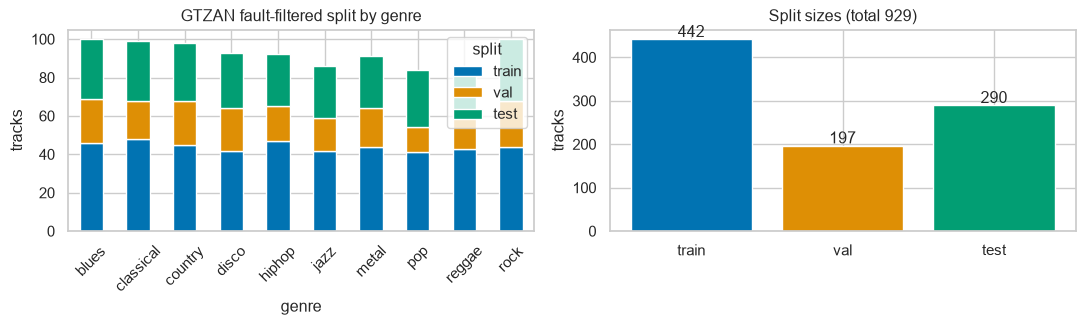

split,train,val,test
genre,,,
blues,46,23,31
classical,48,20,31
country,45,23,30
disco,42,22,29
hiphop,47,18,27
jazz,42,17,27
metal,44,20,27
pop,41,13,30
reggae,43,17,26


A balanced 10-class problem: chance accuracy = 0.100; a majority-class predictor scores macro-F1 ~= 0.018


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ct = pd.crosstab(gtzan["genre"], gtzan["split"])
ct = ct[[c for c in ("train", "val", "test") if c in ct.columns]]
ct.plot(kind="bar", stacked=True, ax=axes[0], color=[PALETTE[0], PALETTE[1], PALETTE[2]])
axes[0].set(ylabel="tracks", title="GTZAN fault-filtered split by genre")
axes[0].tick_params(axis="x", rotation=45)

sizes = gtzan["split"].value_counts().reindex(["train", "val", "test"]).dropna()
axes[1].bar(sizes.index, sizes.values, color=[PALETTE[0], PALETTE[1], PALETTE[2]])
for i, v in enumerate(sizes.values):
    axes[1].text(i, v + 5, str(int(v)), ha="center")
axes[1].set(ylabel="tracks", title=f"Split sizes (total {len(gtzan)})")
plt.tight_layout(); plt.show()

display(ct)
print("A balanced 10-class problem: chance accuracy = 0.100; a majority-class "
      "predictor scores macro-F1 ~= 0.018")

## 4. DEAM: the valence/arousal circumplex

DEAM gives continuous affect ratings on a 1–9 scale. Two facts from this plot drive
design decisions:

* the ratings are **not** uniformly spread over the plane — they cluster near the
  centre, so MAE has to be read against the spread of the targets, not against the
  full 1–9 range;
* valence and arousal are correlated, so a model that predicts one well is partly
  getting the other for free.

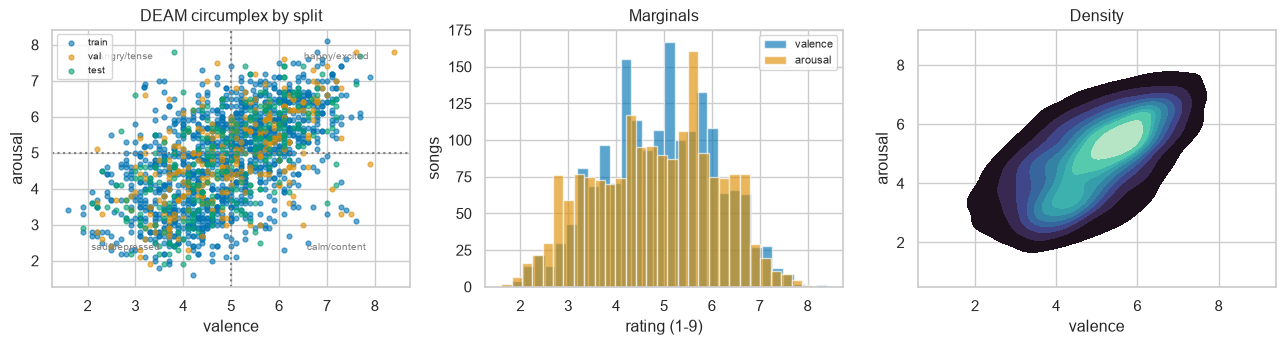

valence: mean 4.90  sd 1.17
arousal: mean 4.81  sd 1.28
corr(valence, arousal) = 0.570
mean-predictor MAE on valence: 0.968  <- the number any model must beat
mean-predictor MAE on arousal: 1.075  <- the number any model must beat


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for split, c in (("train", PALETTE[0]), ("val", PALETTE[1]), ("test", PALETTE[2])):
    s = deam["split"] == split
    axes[0].scatter(deam.loc[s, "valence"], deam.loc[s, "arousal"], s=12, alpha=0.6,
                    label=split, color=c)
axes[0].axhline(5, ls=":", color="grey"); axes[0].axvline(5, ls=":", color="grey")
for x, y, t in ((7.2, 7.6, "happy/excited"), (2.8, 7.6, "angry/tense"),
                (2.8, 2.3, "sad/depressed"), (7.2, 2.3, "calm/content")):
    axes[0].text(x, y, t, fontsize=7, ha="center", color="grey")
axes[0].set(xlabel="valence", ylabel="arousal", title="DEAM circumplex by split")
axes[0].legend(fontsize=7)

axes[1].hist(deam["valence"], bins=30, alpha=0.65, label="valence", color=PALETTE[0])
axes[1].hist(deam["arousal"], bins=30, alpha=0.65, label="arousal", color=PALETTE[1])
axes[1].set(xlabel="rating (1-9)", ylabel="songs", title="Marginals")
axes[1].legend(fontsize=8)

sns.kdeplot(x=deam["valence"], y=deam["arousal"], fill=True, cmap="mako", ax=axes[2])
axes[2].set(title="Density")
plt.tight_layout(); plt.show()

print(f"valence: mean {deam['valence'].mean():.2f}  sd {deam['valence'].std():.2f}")
print(f"arousal: mean {deam['arousal'].mean():.2f}  sd {deam['arousal'].std():.2f}")
print(f"corr(valence, arousal) = {deam['valence'].corr(deam['arousal']):.3f}")
for k in ("valence", "arousal"):
    mae = (deam[k] - deam[k].mean()).abs().mean()
    print(f"mean-predictor MAE on {k}: {mae:.3f}  <- the number any model must beat")

## 5. From audio to graph, one track end to end

This is the core of the preprocessing pipeline. A track becomes a graph in four steps:

1. **frame features** — log-mel (128), chroma (12), MFCC (20) + deltas
2. **segmentation** — beat-synchronous boundaries, so a node is a musically meaningful
   span rather than a fixed window
3. **node features** — per-segment statistics, z-scored
4. **edges** — temporal (i → i+1) and similarity (cosine > τ, top-k)

In [10]:
import librosa
import librosa.display

from src.audio_features import (extract_features, load_audio, node_feature_dim,
                                segment_bounds, segment_features)

track = gtzan[gtzan["split"] == "test"].iloc[0]
print("track:", track["track_id"], "| genre:", track["genre"])

y, sr = load_audio(track["path"], cfg)
tf = extract_features(track["path"], cfg, track_id=track["track_id"])
print(f"audio {len(y)/sr:.1f}s @ {sr} Hz -> {tf.n_frames} frames")
print(f"node feature dim = {node_feature_dim(cfg)}")

track: blues.00012 | genre: blues


U:\v\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


audio 30.0s @ 22050 Hz -> 1292 frames
node feature dim = 340


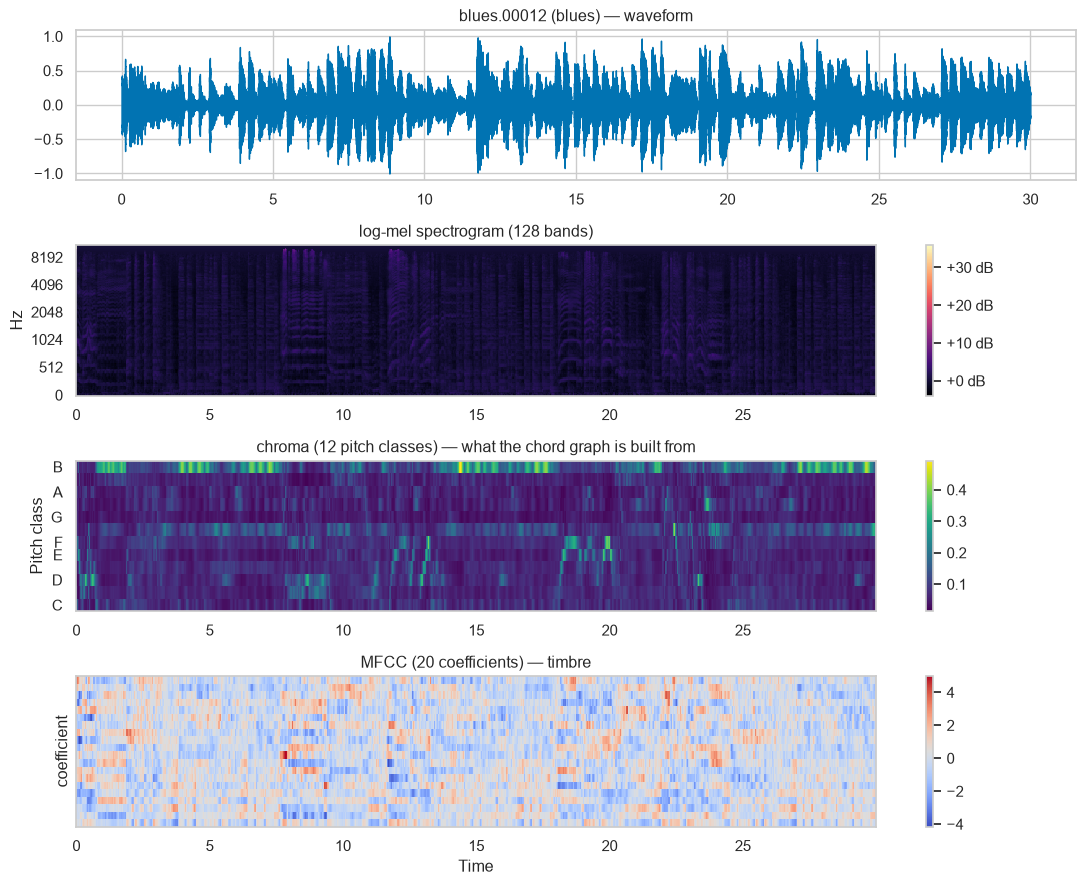

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9))
hop = cfg["audio"]["hop_length"]

librosa.display.waveshow(y, sr=sr, ax=axes[0], color=PALETTE[0])
axes[0].set(title=f"{track['track_id']} ({track['genre']}) — waveform", xlabel="")

img = librosa.display.specshow(tf.mel, sr=sr, hop_length=hop, x_axis="time",
                               y_axis="mel", ax=axes[1], cmap="magma")
axes[1].set(title="log-mel spectrogram (128 bands)", xlabel="")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

img = librosa.display.specshow(tf.chroma, sr=sr, hop_length=hop, x_axis="time",
                               y_axis="chroma", ax=axes[2], cmap="viridis")
axes[2].set(title="chroma (12 pitch classes) — what the chord graph is built from", xlabel="")
fig.colorbar(img, ax=axes[2])

img = librosa.display.specshow(tf.mfcc, sr=sr, hop_length=hop, x_axis="time",
                               ax=axes[3], cmap="coolwarm")
axes[3].set(title="MFCC (20 coefficients) — timbre", ylabel="coefficient")
fig.colorbar(img, ax=axes[3])
plt.tight_layout(); plt.show()

### 5b. Segment boundaries

Boundaries are placed on beats where beat tracking succeeds, and on a fixed grid
otherwise. Beat-synchronous nodes mean the graph's "time step" is a musical unit, so a
similarity edge between two nodes compares comparable spans.

18 segments -> X is 18 nodes x 340 features
seg_chroma (18, 12) (12 pitch classes per node, used by the chord graph)


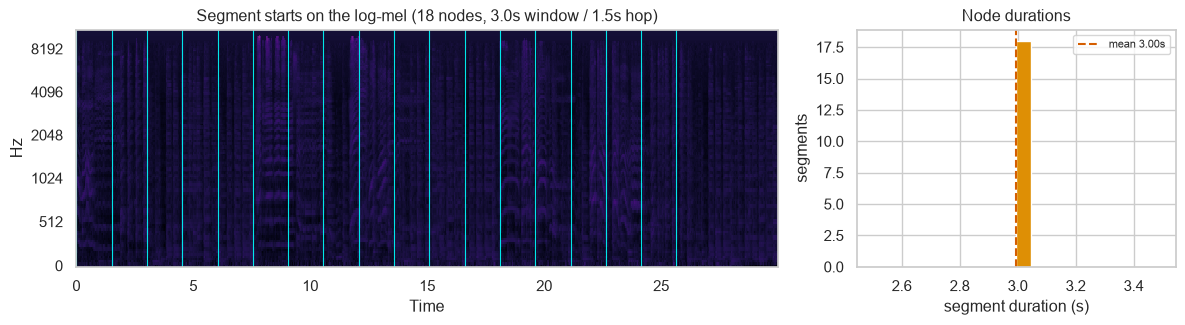

In [12]:
# segment_bounds returns (n_nodes, 2) frame pairs [start, end) -- overlapping, so
# node spans are not a partition of the track. segment_features returns
# (node_x, seg_chroma, bounds); the chroma copy is what the chord graph reads.
bounds = segment_bounds(tf, cfg)
X, seg_chroma, _ = segment_features(tf, cfg)
fps = sr / cfg["audio"]["hop_length"]
print(f"{bounds.shape[0]} segments -> X is {X.shape[0]} nodes x {X.shape[1]} features")
print(f"seg_chroma {seg_chroma.shape} (12 pitch classes per node, used by the chord graph)")
dur = (bounds[:, 1] - bounds[:, 0]) / fps
starts = bounds[:, 0] / fps

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [2.2, 1]})
librosa.display.specshow(tf.mel, sr=sr, hop_length=cfg["audio"]["hop_length"],
                         x_axis="time", y_axis="mel", ax=axes[0], cmap="magma")
for s in starts:
    axes[0].axvline(s, color="cyan", lw=0.8, alpha=0.9)
axes[0].set(title=f"Segment starts on the log-mel ({X.shape[0]} nodes, "
                  f"{cfg['graph']['segment_seconds']}s window / "
                  f"{cfg['graph']['segment_hop_seconds']}s hop)")

axes[1].hist(dur, bins=20, color=PALETTE[1])
axes[1].axvline(dur.mean(), ls="--", color=PALETTE[3], label=f"mean {dur.mean():.2f}s")
axes[1].set(xlabel="segment duration (s)", ylabel="segments", title="Node durations")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 5c. Node feature matrix and adjacency

The block structure visible in the cosine matrix is the *musical form* of the track —
verse/chorus repetition shows up as off-diagonal blocks. That structure is exactly what
the GNN's similarity edges expose to message passing, and it is invisible to a model
that mean-pools the same features.

Data(x=[18, 340], edge_index=[2, 42], edge_attr=[42, 3], edge_weight=[42], num_nodes=18, track_id='blues.00012', graph_kind='segment', seg_bounds=[18, 2], seg_chroma=[18, 12], chords=[18], frames_per_second=43.06640625)


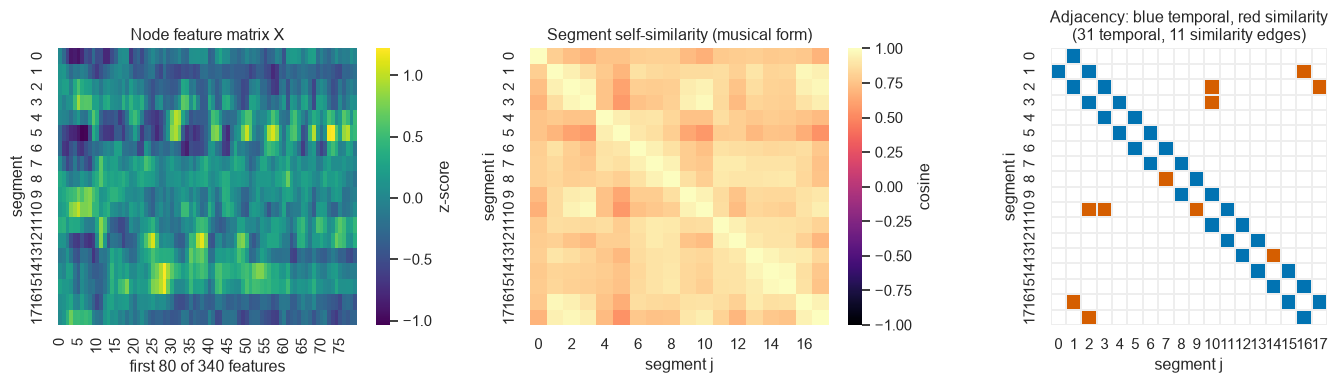

In [13]:
from src.graph_builder import build_segment_graph

g = build_segment_graph(tf, cfg)
print(g)

Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)
S = Xn @ Xn.T

A = np.zeros((g.num_nodes, g.num_nodes))
ei, ea = g.edge_index.numpy(), g.edge_attr.numpy()
for e in range(ei.shape[1]):
    A[ei[0, e], ei[1, e]] = 2.0 if ea[e, 2] > 0.5 else 1.0

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.heatmap(X[:, :80], cmap="viridis", ax=axes[0], cbar_kws={"label": "z-score"})
axes[0].set(xlabel=f"first 80 of {X.shape[1]} features", ylabel="segment",
            title="Node feature matrix X")

sns.heatmap(S, cmap="magma", ax=axes[1], vmin=-1, vmax=1, cbar_kws={"label": "cosine"})
axes[1].set(xlabel="segment j", ylabel="segment i",
            title="Segment self-similarity (musical form)")

sns.heatmap(A, cmap=sns.color_palette(["white", PALETTE[0], PALETTE[3]], as_cmap=True),
            ax=axes[2], cbar=False, square=True, linewidths=0.2, linecolor="#eeeeee")
axes[2].set(xlabel="segment j", ylabel="segment i",
            title=f"Adjacency: blue temporal, red similarity\n"
                  f"({int(ea[:, 1].sum())} temporal, {int(ea[:, 2].sum())} similarity edges)")
plt.tight_layout(); plt.show()

## 6. Calibrating the similarity threshold τ

τ is the one graph hyperparameter with no principled default. Too low and every node
connects to every other, so message passing averages the whole track and the graph
carries no information; too high and only temporal edges survive and the model reduces
to a sequence.

The sweep below is the evidence behind `graph.similarity_threshold`. Note the scale:
raw feature cosines on z-scored segment statistics are high across the board, so a
threshold like 0.5 would connect essentially everything.

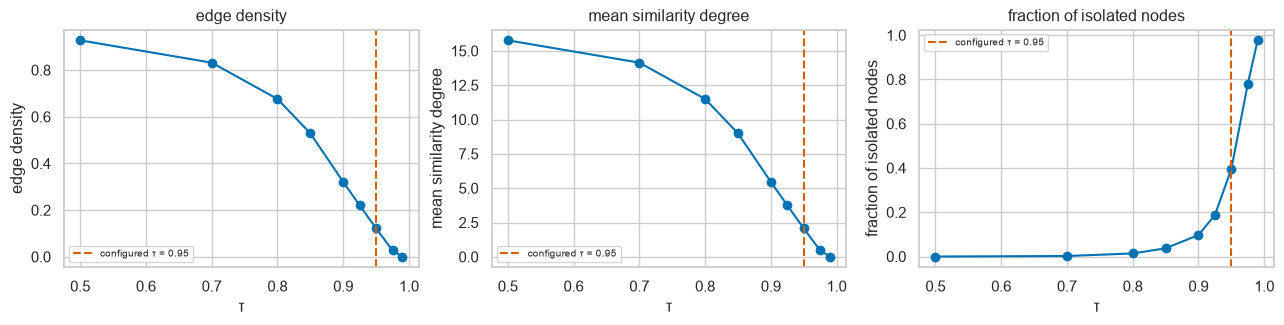

,tau,density,mean_degree,isolated
0,0.500,0.9276,15.7685,0.0000
1,0.700,0.8320,14.1435,0.0023
2,0.800,0.6765,11.5000,0.0139
3,0.850,0.5291,8.9954,0.0370
4,0.900,0.3211,5.4583,0.0972
5,0.925,0.2209,3.7546,0.1875
6,0.950,0.1220,2.0741,0.3958
7,0.975,0.0272,0.4630,0.7801
8,0.990,0.0014,0.0231,0.9769


In [14]:
sub = gtzan[gtzan["split"] == "train"].sample(24, random_state=cfg["seed"])
taus = [0.5, 0.7, 0.8, 0.85, 0.9, 0.925, 0.95, 0.975, 0.99]
rows = []
for _, r in sub.iterrows():
    t = extract_features(r["path"], cfg, track_id=r["track_id"])
    Xi, _, _ = segment_features(t, cfg)
    Xi = Xi / (np.linalg.norm(Xi, axis=1, keepdims=True) + 1e-9)
    Si = Xi @ Xi.T
    np.fill_diagonal(Si, -np.inf)
    n = Si.shape[0]
    for tau in taus:
        m = Si > tau
        rows.append({"tau": tau, "density": m.sum() / max(1, n * (n - 1)),
                     "mean_degree": m.sum() / max(1, n),
                     "isolated": float((m.sum(1) == 0).mean())})
sweep = pd.DataFrame(rows).groupby("tau").mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, key, lbl in zip(axes, ("density", "mean_degree", "isolated"),
                        ("edge density", "mean similarity degree",
                         "fraction of isolated nodes")):
    ax.plot(sweep["tau"], sweep[key], marker="o", color=PALETTE[0])
    ax.axvline(cfg["graph"]["similarity_threshold"], ls="--", color=PALETTE[3],
               label=f"configured τ = {cfg['graph']['similarity_threshold']}")
    ax.set(xlabel="τ", ylabel=lbl, title=lbl)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()
display(sweep.round(4))

## 7. Chord-transition graphs

A second, much sparser view of the same track: nodes are chord labels estimated by
template matching over chroma, edges are observed transitions. This graph discards
timbre entirely and keeps harmony, so it is a clean test of *what kind* of structure
the genre signal lives in — the Task 2 ablation table compares the two directly.

Data(x=[3, 40], edge_index=[2, 4], edge_attr=[4, 3], edge_weight=[4], num_nodes=3, track_id='blues.00012', graph_kind='chord', chord_vocab=[3], chord_seq=[8])
chord nodes: ['E:maj', 'B:maj', 'B:min']


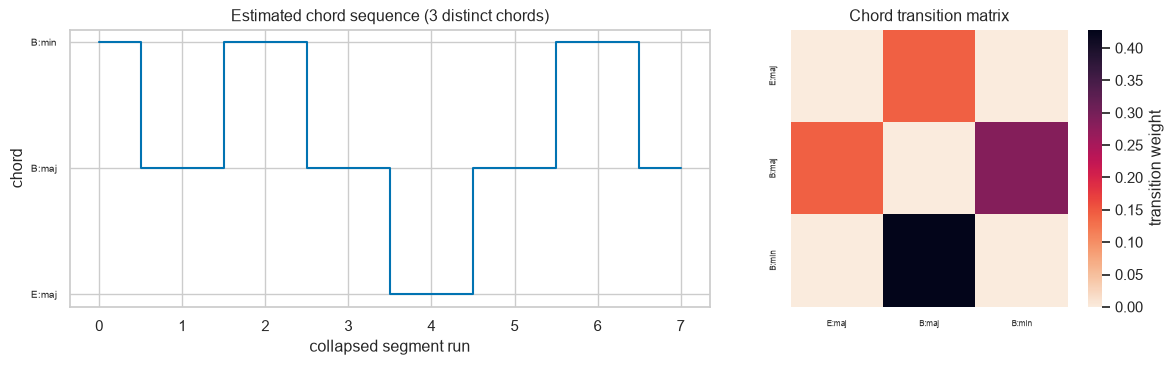

In [15]:
from src.graph_builder import build_chord_graph

cg = build_chord_graph(tf, cfg)
print(cg)
labels = [str(c) for c in getattr(cg, "chord_vocab", [])]
print("chord nodes:", labels[:20])

An = np.zeros((cg.num_nodes, cg.num_nodes))
cei = cg.edge_index.numpy()
w = (cg.edge_weight.numpy() if getattr(cg, "edge_weight", None) is not None
     else np.ones(cei.shape[1]))
for e in range(cei.shape[1]):
    An[cei[0, e], cei[1, e]] = w[e]

seq = [str(s) for s in getattr(cg, "chord_seq", [])]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1.6, 1]})
if seq:
    idx = {c: i for i, c in enumerate(labels)}
    axes[0].step(range(len(seq)), [idx.get(s, -1) for s in seq], where="mid", color=PALETTE[0])
    axes[0].set_yticks(range(len(labels)))
    axes[0].set_yticklabels(labels, fontsize=7)
axes[0].set(xlabel="collapsed segment run", ylabel="chord",
            title=f"Estimated chord sequence ({len(labels)} distinct chords)")

sns.heatmap(An, cmap="rocket_r", ax=axes[1], square=True,
            xticklabels=labels or "auto", yticklabels=labels or "auto",
            cbar_kws={"label": "transition weight"})
axes[1].set(title="Chord transition matrix")
axes[1].tick_params(labelsize=6)
plt.tight_layout(); plt.show()

## 8. Graph statistics across the whole cache

The distributions below decide the GNN depth. With a small graph diameter, three
message-passing layers already give most nodes a receptive field covering the entire
track — going deeper mainly buys oversmoothing, which is what the graph-coherence
analysis in the paper then measures.

,graphs,nodes_mean,nodes_min,nodes_max,edges_mean,degree_mean,node_dim
corpus,,,,,,,
gtzan/segment,929,18.00,18,18,50.99,2.83,340
deam/segment,1802,18.00,18,18,49.42,2.75,340
musiccaps/segment,1507,12.00,12,12,24.67,2.06,340
gtzan/chord,929,5.17,1,12,7.00,1.34,40


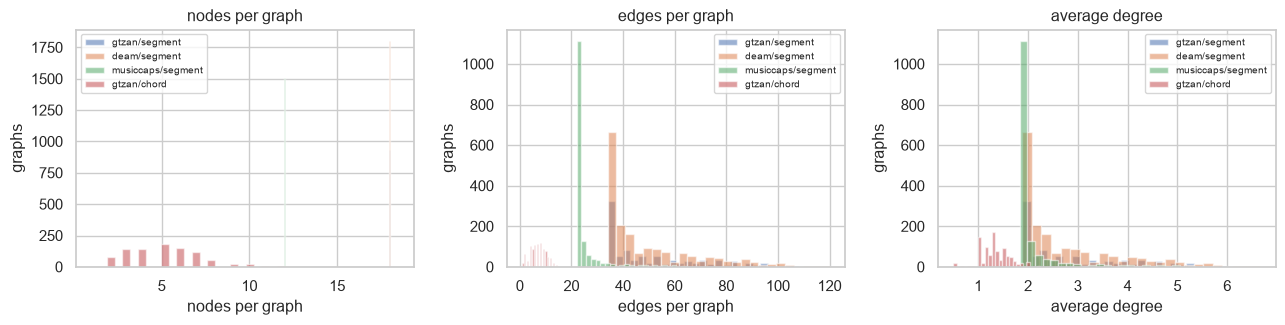

In [16]:
from src.graph_dataset import load_cached_graphs

stats, per_corpus = [], {}
for ds, kind in (("gtzan", "segment"), ("deam", "segment"),
                 ("musiccaps", "segment"), ("gtzan", "chord")):
    try:
        gs = load_cached_graphs(cfg, ds, kind)
    except FileNotFoundError:
        print(f"  (no cache for {ds}/{kind} — run scripts/preprocess.py)")
        continue
    n = np.array([int(x.num_nodes) for x in gs])
    e = np.array([int(x.edge_index.shape[1]) for x in gs])
    per_corpus[f"{ds}/{kind}"] = (n, e)
    stats.append({"corpus": f"{ds}/{kind}", "graphs": len(gs),
                  "nodes_mean": n.mean(), "nodes_min": n.min(), "nodes_max": n.max(),
                  "edges_mean": e.mean(), "degree_mean": (e / np.maximum(n, 1)).mean(),
                  "node_dim": int(gs[0].x.shape[1])})
display(pd.DataFrame(stats).set_index("corpus").round(2))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for name, (n, e) in per_corpus.items():
    axes[0].hist(n, bins=25, alpha=0.55, label=name)
    axes[1].hist(e, bins=25, alpha=0.55, label=name)
    axes[2].hist(e / np.maximum(n, 1), bins=25, alpha=0.55, label=name)
for ax, t in zip(axes, ("nodes per graph", "edges per graph", "average degree")):
    ax.set(xlabel=t, ylabel="graphs", title=t); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

In [17]:
# Receptive field: how far does message passing actually reach?
import collections

def bfs_reach(graphs, k=60):
    out = []
    for g in graphs[:k]:
        n = int(g.num_nodes)
        adj = collections.defaultdict(set)
        ei = g.edge_index.numpy()
        for a, b in zip(ei[0], ei[1]):
            adj[int(a)].add(int(b)); adj[int(b)].add(int(a))
        seen, frontier, d = {0}, [0], 0
        while frontier and d < 20:
            nxt = [v for u in frontier for v in adj[u] if v not in seen]
            if not nxt:
                break
            seen.update(nxt); frontier = nxt; d += 1
        out.append((d, len(seen) / n))
    return np.array(out)

gs = load_cached_graphs(cfg, "gtzan", "segment")
h = bfs_reach(gs)
print(f"BFS from node 0 over {len(h)} GTZAN segment graphs:")
print(f"  mean hops to exhaust the component : {h[:, 0].mean():.2f}")
print(f"  mean fraction of nodes reached     : {h[:, 1].mean():.3f}")
print(f"  configured GNN depth               : {cfg['model']['gnn']['num_layers']} layers")
print()
print("With this diameter, 3 layers already cover most of a track. That is why the "
      "paper reports graph coherence: the risk here is oversmoothing, not "
      "under-reaching.")

BFS from node 0 over 60 GTZAN segment graphs:
  mean hops to exhaust the component : 10.92
  mean fraction of nodes reached     : 1.000
  configured GNN depth               : 3 layers

With this diameter, 3 layers already cover most of a track. That is why the paper reports graph coherence: the risk here is oversmoothing, not under-reaching.


## 9. What the EDA settled

| observation | consequence in the code |
|---|---|
| captions average ~54 wordpieces, p95 ≈ 91 | `text.max_length = 192` truncates nothing; dynamic padding per batch is the real speedup |
| tags are derived from captions | Task 1 gets a lexical-match baseline **and** a masked-caption variant; the gap is reported |
| tag support spans two orders of magnitude | macro-F1 is the headline metric; thresholds tuned on validation |
| GTZAN has artist leakage under random splits | fault-filtered partition; numbers not comparable to random-split literature |
| DEAM ratings cluster near the centre and V/A correlate | MAE reported against a mean-predictor baseline, both dimensions reported |
| segment cosines are high on z-scored features | τ calibrated to 0.95, not a naive 0.5 |
| graph diameter is small | 3 GNN layers; oversmoothing measured explicitly via graph coherence |
| MusicCaps audio must be recovered from YouTube | recovery rate measured and reported with every MusicCaps result |